In [3]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np

In [148]:
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Client_Survey1.csv')

In [ ]:
df2 = pd.read_csv('Client_Survey_Git.csv')

In [125]:
df_clean= pd.read_csv('Clean_Headers.csv')

<h1> Categorical Survey

In [135]:
df.head(2)

,Timestamp,Your Gender,Your Age,Your current occupation?,What is your annual income?,How often do you visit Elevate?,How do you usually enjoy Elevate?,How much time do you normally spend during your visit?,The nearest Elevate's outlet to you is...?,Do you have Elevate membership card?,...,"On average, how much would you spend at Elevate per visit?","How would you rate the quality of Elevate compared to other brands (Coffee Bean, Old Town White Coffee..) to be:",How would you rate the price range at Elevate?,How important are sales and promotions in your purchase decision?,"How would you rate the ambiance at Elevate? (lighting, music, etc...)",You rate the WiFi quality at Elevate as..,"How would you rate the service at Elevate? (Promptness, friendliness, etc..)",How likely you will choose Elevate for doing business meetings or hangout with friends?,How do you come to hear of promotions at Elevate? Check all that apply.,Will you continue buying at Elevate?
0,2019/10/01 12:38:43 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Dine in,Between 30 minutes to 1 hour,within 1km,Yes,...,Less than RM20,4,3,5,5,4,4,3,Starbucks Website/Apps;Social Media;Emails;Dea...,Yes
1,2019/10/01 12:38:54 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,1km - 3km,Yes,...,Less than RM20,4,3,4,4,4,5,2,Social Media;In Store displays,Yes


<h1> Numerical Data

In [46]:
df2.head(5)

,Id,gender,age,status,income,visitNo,method,timeSpend,location,membershipCard,...,chooseRate,promoMethodApp,promoMethodSoc,promoMethodEmail,promoMethodDeal,promoMethodFriend,promoMethodDisplay,promoMethodBillboard,promoMethodOthers,loyal
0,1,1,1,0,0,3,0,1,0,0,...,3,1,1,1,1,1,1,1,1,0
1,2,1,1,0,0,3,2,0,1,0,...,2,1,1,1,1,1,1,1,1,0
2,3,0,1,2,0,2,0,1,2,0,...,3,1,1,1,1,1,1,1,1,0
3,4,1,1,0,0,3,2,0,2,1,...,3,1,1,1,1,1,1,1,1,1
4,5,0,1,0,0,2,2,1,1,1,...,3,1,1,1,1,1,1,1,1,0


In [47]:
df2.shape

(113, 33)

<h1> Survey Questions</h1>
<h3> Ratings 1- 5 </h3></br>
<ul>
    <li>Timestamp</li>
    <li>Your Gender</li>
    <li>Your Age</li>
    <li>Your current occupation?</li>
    <li>What is your annual income?</li>
    <li>How often do you visit Elevate?</li>
    <li>How do you usually enjoy Elevate?</li>
    <li>How much time do you normally spend during your visit?</li>
    <li>The nearest Elevate's outlet to you is...?</li>
    <li>Do you have Elevate membership card?</li>
    <li>What do you most frequently purchase at Elevate?</li>
    <li>On average, how much would you spend at Elevate per visit?</li>
    <li>How would you rate the quality of Elevate compared to other brands (Coffee Bean, Old Town White Coffee..) to be:</li>
    <li>How would you rate the price range at Elevate?</li>
    <li>How important are sales and promotions in your purchase decision?</li>
    <li>How would you rate the ambiance at Elevate? (lighting, music, etc...)</li>
    <li>You rate the WiFi quality at Elevate as..</li>
    <li>How would you rate the service at Elevate? (Promptness, friendliness, etc..)</li>
    <li>How likely you will choose Elevate for doing business meetings or hangout with friends?</li>
    <li>How do you come to hear of promotions at Elevate? Check all that apply.</li>
    <li>Will you continue buying at Elevate?</li>
</ul>


<h2> Factors effecting Loyality </h2>

In [53]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [63]:
df2.columns

Index(['Id', 'gender', 'age', 'status', 'income', 'visitNo', 'method',
       'timeSpend', 'location', 'membershipCard', 'itemPurchaseCoffee',
       'itempurchaseCold', 'itemPurchasePastries', 'itemPurchaseJuices',
       'itemPurchaseSandwiches', 'itemPurchaseOthers', 'spendPurchase',
       'productRate', 'priceRate', 'promoRate', 'ambianceRate', 'wifiRate',
       'serviceRate', 'chooseRate', 'promoMethodApp', 'promoMethodSoc',
       'promoMethodEmail', 'promoMethodDeal', 'promoMethodFriend',
       'promoMethodDisplay', 'promoMethodBillboard', 'promoMethodOthers',
       'loyal'],
      dtype='object')

In [87]:
#Make Random Forest
X = df2.drop(columns=['loyal', 'Id','productRate', 'priceRate', 'promoRate', 'ambianceRate', 'wifiRate',
       'serviceRate', 'chooseRate', 'promoMethodApp', 'promoMethodSoc',
       'promoMethodEmail', 'promoMethodDeal', 'promoMethodFriend',
       'promoMethodDisplay', 'promoMethodBillboard', 'promoMethodOthers','itempurchaseCold', 'itemPurchasePastries', 'itemPurchaseJuices',
       'itemPurchaseSandwiches', 'itemPurchaseOthers', 'spendPurchase'])  # Exclude target and ID
y = df2['loyal']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=1000,         # Number of trees
    max_depth=10,             # Maximum depth of each tree
    min_samples_split=2,      # Minimum samples needed to split a node
    min_samples_leaf=3,       # Minimum samples needed at a leaf node
    max_features='sqrt',      # Features to consider when looking for the best split
    bootstrap=True,           # Use bootstrapped samples
    random_state=42           # For reproducibility
)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.2%}")

Random Forest Accuracy: 78.26%


In [84]:
# Get feature importance
importances = rf.feature_importances_
coefficients = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
coefficients = coefficients.sort_values(by='Importance', ascending=False)

In [85]:
coefficients.sort_values(by="Importance", ascending = False)

,Feature,Importance
8,membershipCard,0.218662
4,visitNo,0.187653
2,status,0.125966
5,method,0.117556
6,timeSpend,0.086875
7,location,0.079176
0,gender,0.068543
3,income,0.067287
1,age,0.048281
9,itemPurchaseCoffee,0.000000


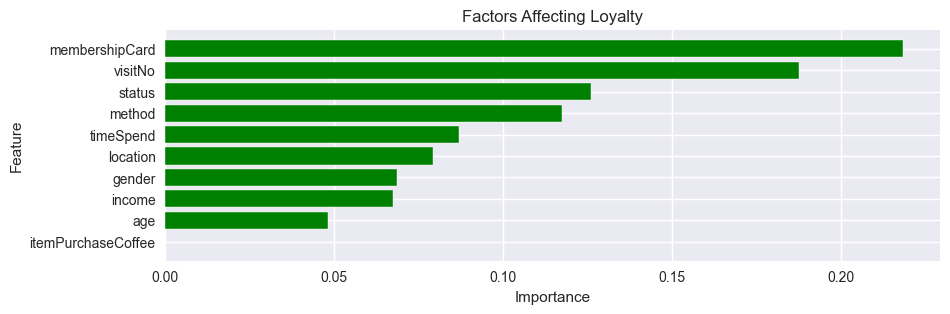

In [86]:
# Plot feature importance
plt.figure(figsize=(10, 3))
plt.barh(coefficients['Feature'], coefficients['Importance'], color='green')
plt.title('Factors Affecting Loyalty')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Invert y-axis for better visibility
plt.show()

<h2> Analysis - Factors that Effect Loyality</h2><br>
We will ignore loyality card because that is a given <br>
1 - No of Visits - Customer Makes <br>
2 - Status - What is occupation Status of Customer <br>
3 - Method - Is the customer sing services in location or online <br>
4 - Time Spend - What is occupation Status of Customer <br>
<br>
<br>


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# Prepare the data (you might need to clean NaNs and normalize)
df2['visit_frequency'] = df2['visitNo'].astype(int)
df2['price_rating'] = df2['priceRate'].astype(int)
df2['loyal'] = df2['loyal'].astype(int)

print(df2[['visit_frequency', 'price_rating', 'loyal']].isna().sum())

visit_frequency    0
price_rating       0
loyal              0
dtype: int64


<h3> Loyality & Price , Frequency of Visit

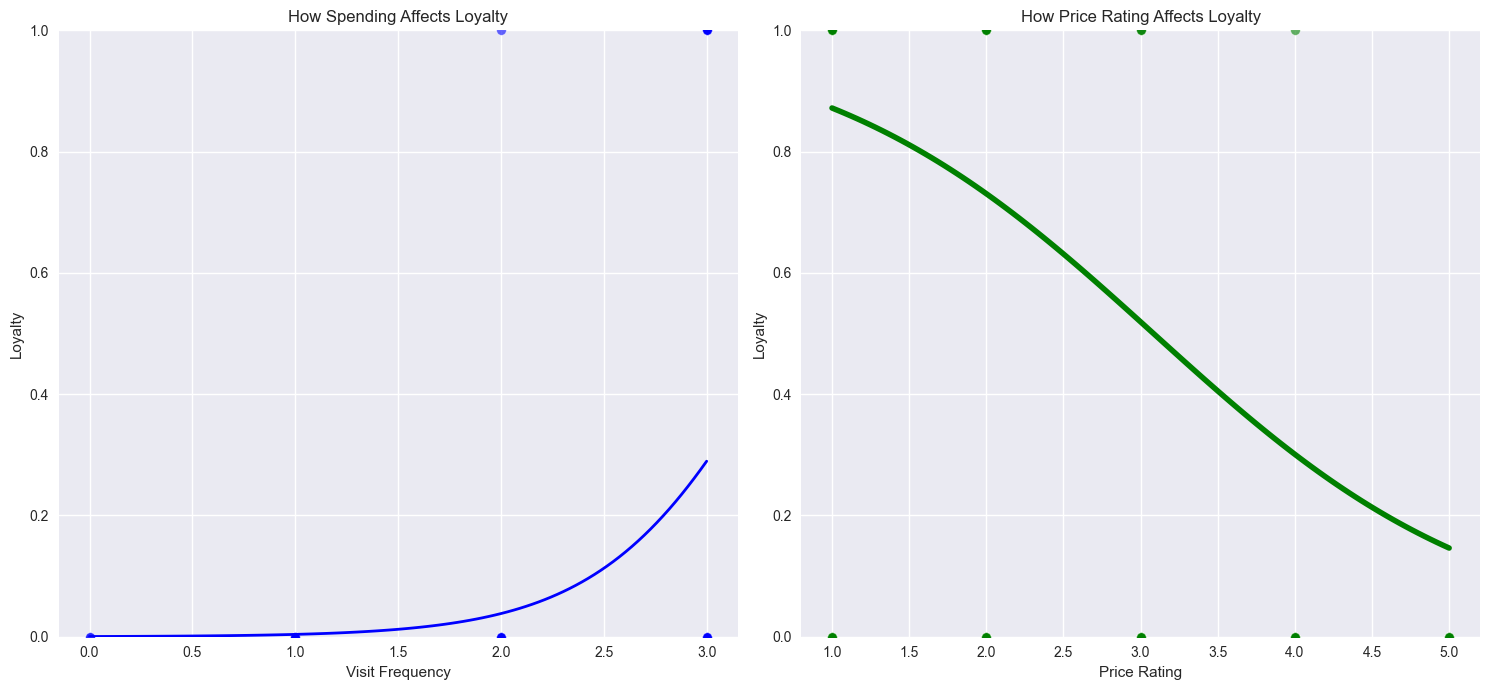

In [91]:

# Remove any NaN values for the columns you are using
df_clean = df2.dropna(subset=['visit_frequency', 'price_rating', 'loyal'])

# Define a logistic curve function for fitting (if needed)
def logistic_curve(x, a, b, c):
    return 1 / (1 + np.exp(-(a * (x - b)) + c))

# Fit curve for visit frequency vs loyalty
popt_visit, _ = curve_fit(logistic_curve, df_clean['visit_frequency'], df_clean['loyal'])

# Fit curve for price rating vs loyalty
popt_price, _ = curve_fit(logistic_curve, df_clean['price_rating'], df_clean['loyal'])

# Generate x values for plotting the curves
x_values = np.linspace(df_clean['visit_frequency'].min(), df_clean['visit_frequency'].max(), 100)
y_values_visit = logistic_curve(x_values, *popt_visit)

x_values_price = np.linspace(df_clean['price_rating'].min(), df_clean['price_rating'].max(), 100)
y_values_price = logistic_curve(x_values, *popt_price)

# Create scatter plots and curve fitting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Visit Frequency vs Loyalty
sns.scatterplot(x='visit_frequency', y='loyal', data=df_clean, ax=axes[0], color='blue', alpha=0.6)
axes[0].plot(x_values, y_values_visit, color='blue', lw=2)
axes[0].set_title('How Spending Affects Loyalty')
axes[0].set_xlabel('Visit Frequency')
axes[0].set_ylabel('Loyalty')
axes[0].set_ylim([0, 1])
axes[0].grid(True)

# Price Rating vs Loyalty
sns.scatterplot(x='price_rating', y='loyal', data=df_clean, ax=axes[1], color='green', alpha=0.6)
axes[1].plot(x_values_price, y_values_price, color='green', lw=4)
axes[1].set_title('How Price Rating Affects Loyalty')
axes[1].set_xlabel('Price Rating')
axes[1].set_ylabel('Loyalty')
axes[1].set_ylim([0, 1])
axes[1].grid(True)

plt.tight_layout()
plt.show()


<h2> Customer Clusters

/Users/user/opt/miniconda3/envs/tf_clustering/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


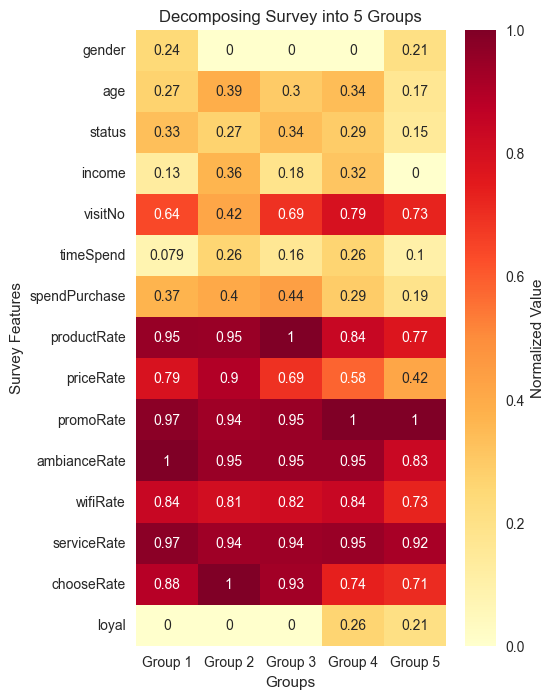

In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Filter relevant numeric columns
relevant_features = ['gender', 'age', 'status', 'income', 'visitNo', 'timeSpend', 'spendPurchase',
                     'productRate', 'priceRate', 'promoRate', 'ambianceRate', 'wifiRate', 'serviceRate', 
                     'chooseRate', 'loyal']  # Adjust based on your dataset
filtered_df = df2[relevant_features]

# Normalize the data
normalized_data = scaler.fit_transform(filtered_df)

# Clustering (e.g., 5 clusters)
df2['cluster'] = kmeans.fit_predict(normalized_data)

# Group by cluster and calculate the mean
grouped_data = df2.groupby('cluster')[relevant_features].mean()

# Transpose the grouped data for better heatmap display
heatmap_data = pd.DataFrame(scaler.fit_transform(grouped_data.T), 
                            index=grouped_data.columns, 
                            columns=[f'Group {i+1}' for i in range(grouped_data.shape[0])])

# Plot heatmap
plt.figure(figsize=(5, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', cbar_kws={'label': 'Normalized Value'})
plt.title('Decomposing Survey into 5 Groups')
plt.ylabel('Survey Features')
plt.xlabel('Groups')
plt.show()


In [111]:
df.columns

Index(['0', '2019/10/01 12:38:43 PM GMT+8', 'Female', 'From 20 to 29',
       'Student', 'Less than RM25,000', 'Rarely', 'Dine in',
       'Between 30 minutes to 1 hour', 'within 1km', 'Yes', 'Coffee',
       'Less than RM20', '4', '3', '5', '5.1', '4.1', '4.2', '3.1',
       'Starbucks Website/Apps;Social Media;Emails;Deal sites (fave, iprice, etc...)',
       'Yes.1'],
      dtype='object')

<h2> Customer Segementation 

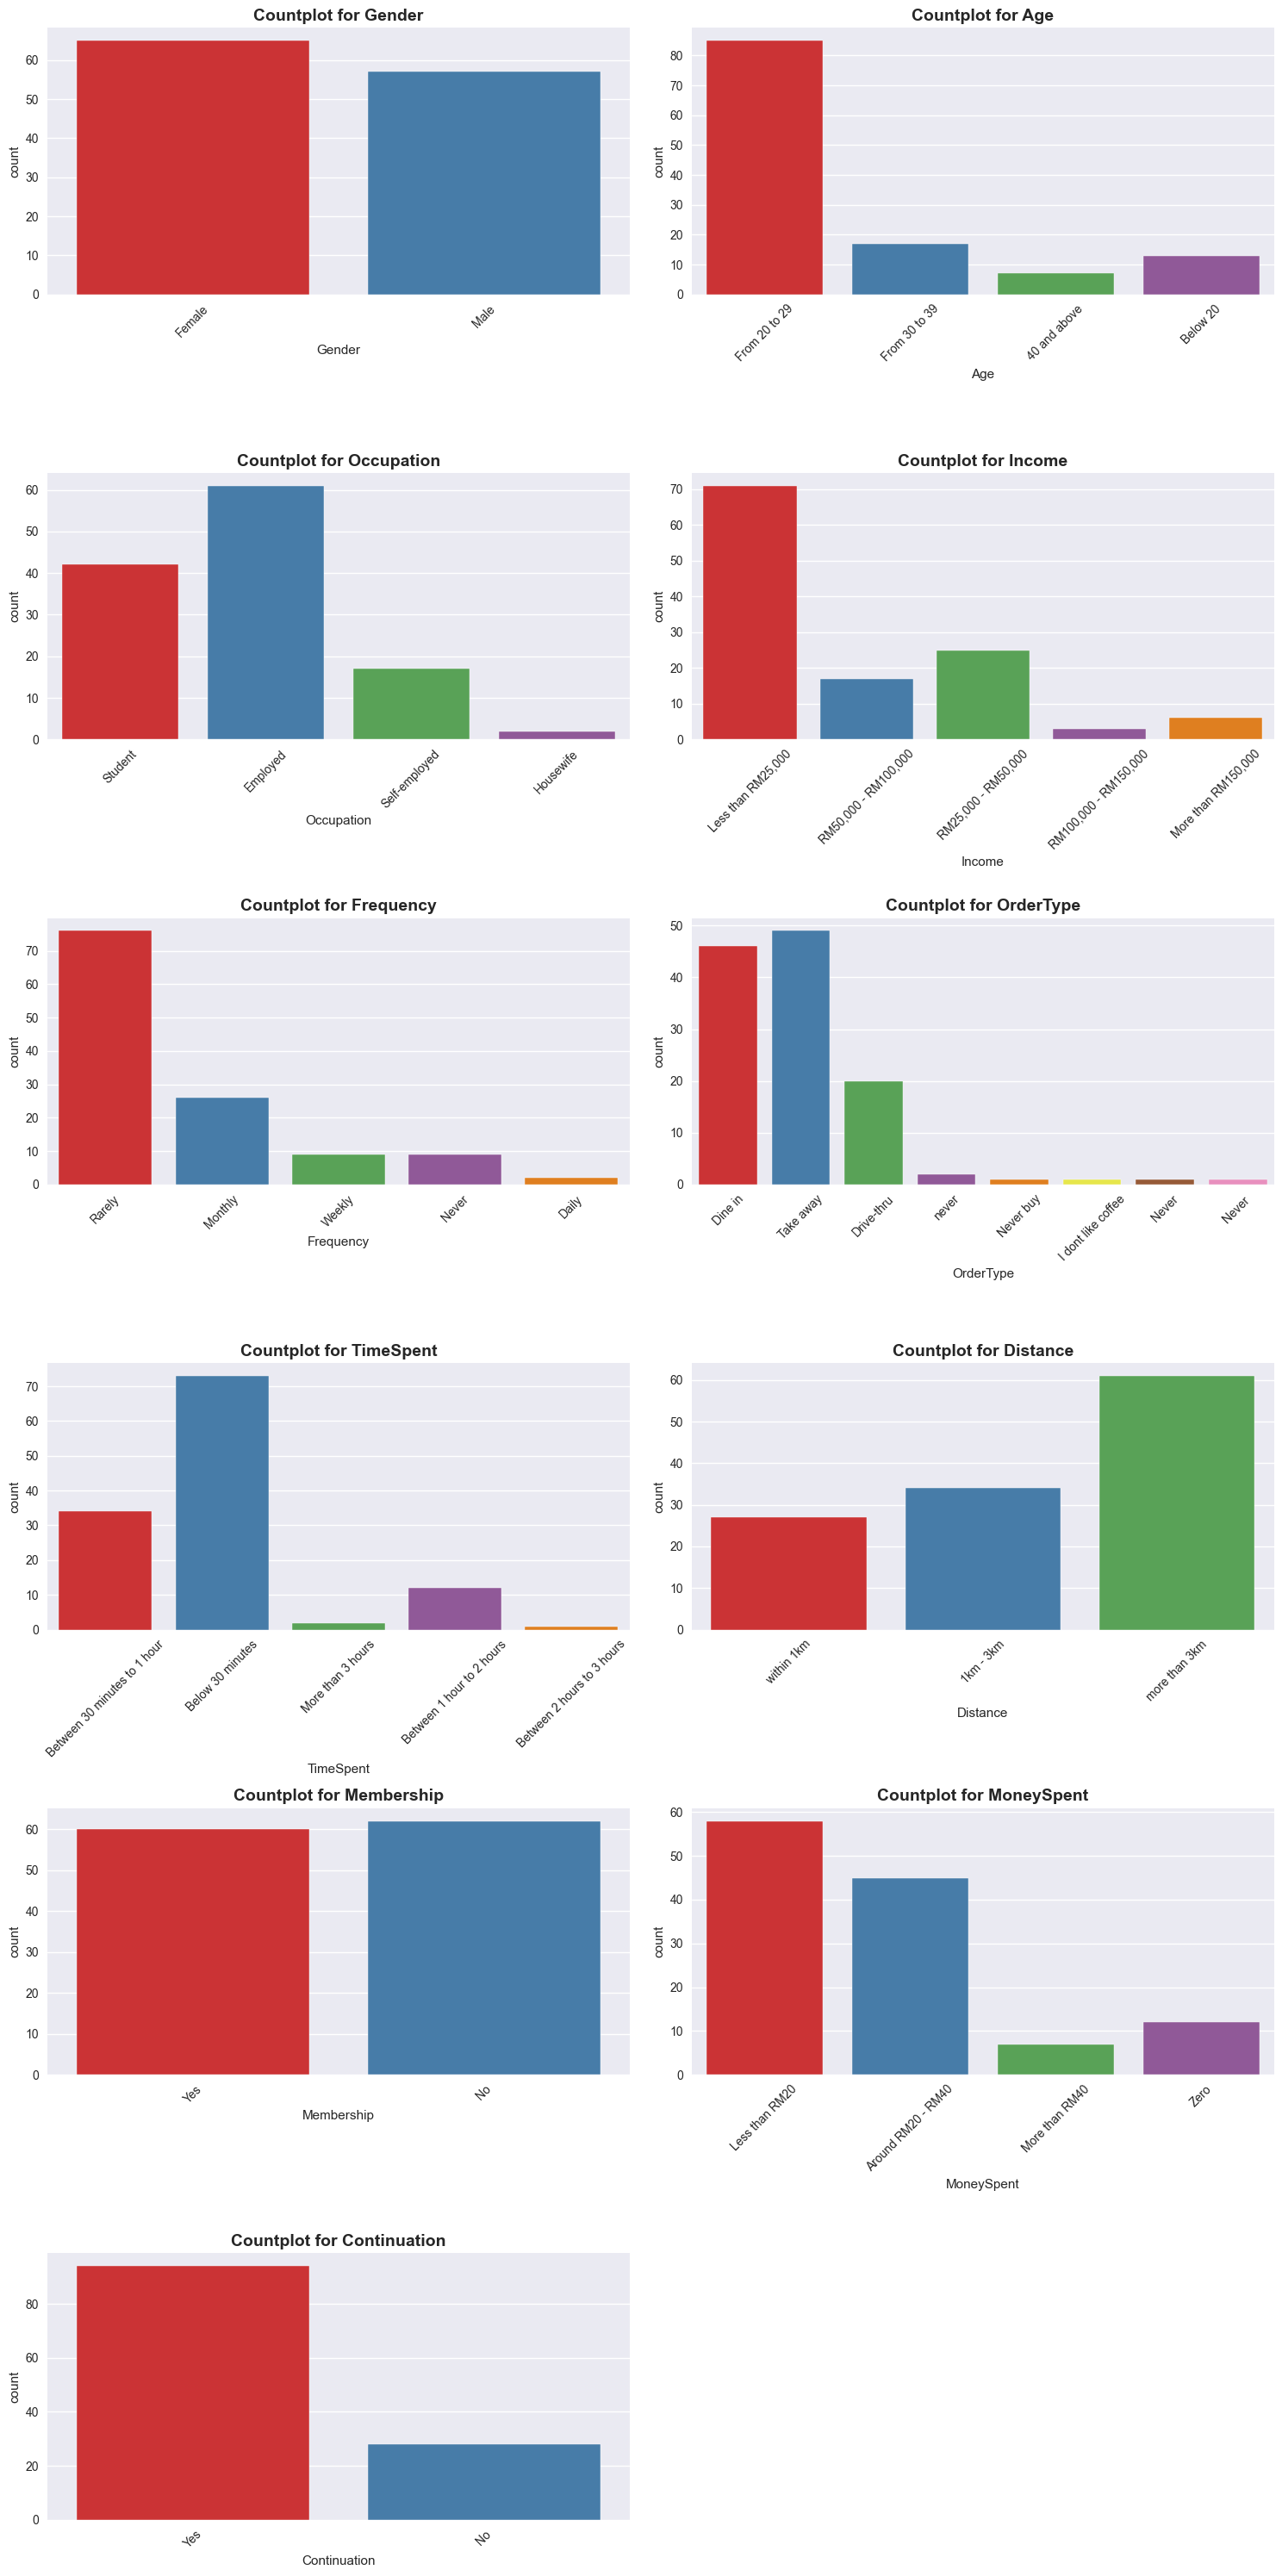

In [131]:
# List of categorical variables
cat = [
    'Gender', 'Age', 'Occupation', 'Income', 'Frequency', 'OrderType', 
    'TimeSpent', 'Distance', 'Membership', 'MoneySpent', 'Continuation'
]

# Number of subplots per row
plots_per_row = 2

# Calculate total rows needed
total_plots = len(cat)
rows = (total_plots + plots_per_row - 1) // plots_per_row  # Ceiling division

# Create subplots
fig, axes = plt.subplots(rows, plots_per_row, figsize=(15, rows * 5))  # Adjust size as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Custom color palette
palette = sns.color_palette("Set1")

# Plot each categorical variable
for idx, col in enumerate(cat):
    sns.countplot(data=df_clean, x=col, ax=axes[idx], palette=palette)  # Add color palette
    axes[idx].set_title(f'Countplot for {col}',fontsize=14, weight='bold')  # Set title for each plot
    axes[idx].tick_params(axis='x', rotation=45)  # Rotate x-axis ticks for better readability

# Remove any unused subplots
for idx in range(total_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


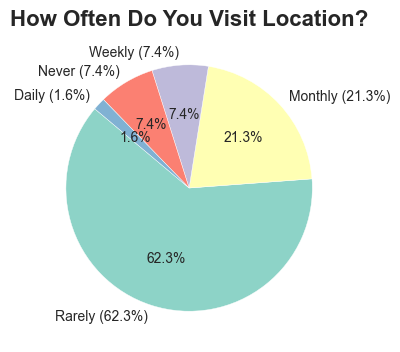

In [137]:
# Calculate value counts and percentages
visit_counts = df['How often do you visit Elevate?'].value_counts()
visit_percentages = visit_counts / visit_counts.sum() * 100

# Create a pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    visit_counts, 
    labels=[f"{label} ({percentage:.1f}%)" for label, percentage in zip(visit_counts.index, visit_percentages)],
    autopct='%1.1f%%',  # This will display percentages inside the chart
    startangle=140,  # Start angle for better alignment
    colors=plt.cm.Set3.colors  # Optional: Custom color palette
)

# Add a title
plt.title('How Often Do You Visit Location?', fontsize=16, weight='bold')

# Display the plot
plt.show()


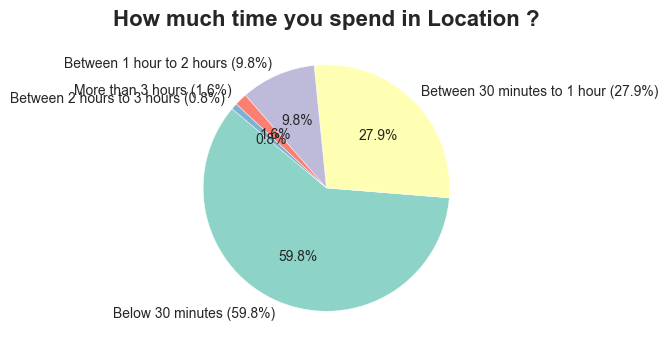

In [141]:
import matplotlib.pyplot as plt

# Calculate value counts and percentages
visit_counts = df['How much time do you normally spend during your visit?'].value_counts()
visit_percentages = visit_counts / visit_counts.sum() * 100

# Create a pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    visit_counts, 
    labels=[f"{label} ({percentage:.1f}%)" for label, percentage in zip(visit_counts.index, visit_percentages)],
    autopct='%1.1f%%',  # This will display percentages inside the chart
    startangle=140,  # Start angle for better alignment
    colors=plt.cm.Set3.colors  # Optional: Custom color palette
)

# Add a title
plt.title('How much time you spend in Location ?', fontsize=16, weight='bold')

# Display the plot
plt.show()


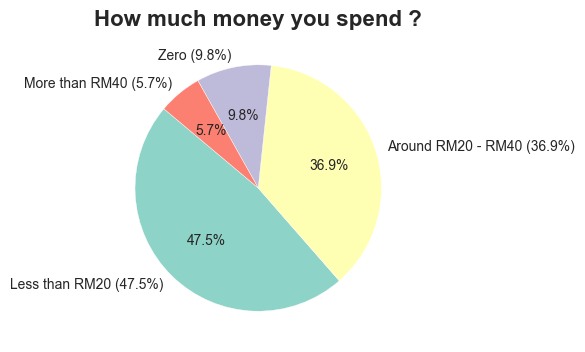

In [140]:
import matplotlib.pyplot as plt

# Calculate value counts and percentages
visit_counts = df['On average, how much would you spend at Elevate per visit?'].value_counts()
visit_percentages = visit_counts / visit_counts.sum() * 100

# Create a pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    visit_counts, 
    labels=[f"{label} ({percentage:.1f}%)" for label, percentage in zip(visit_counts.index, visit_percentages)],
    autopct='%1.1f%%',  # This will display percentages inside the chart
    startangle=140,  # Start angle for better alignment
    colors=plt.cm.Set3.colors  # Optional: Custom color palette
)

# Add a title
plt.title('How much money you spend ?', fontsize=16, weight='bold')

# Display the plot
plt.show()

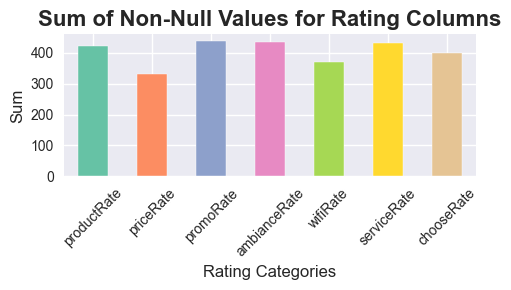

In [143]:
import matplotlib.pyplot as plt

# List of numeric ratings columns
rating_columns = ['productRate', 'priceRate', 'promoRate', 'ambianceRate', 'wifiRate', 'serviceRate', 'chooseRate']

# Count the number of non-null entries for each column
value_counts = df2[rating_columns].sum()

# Create a bar plot
plt.figure(figsize=(5, 3))
value_counts.plot(kind='bar', color=plt.cm.Set2.colors)

# Add labels and title
plt.title('Sum of Non-Null Values for Rating Columns', fontsize=16, weight='bold')
plt.ylabel('Sum', fontsize=12)
plt.xlabel('Rating Categories', fontsize=12)
plt.xticks(rotation=45, fontsize=10)

plt.tight_layout() 
plt.show()

<h2> Survey ratings

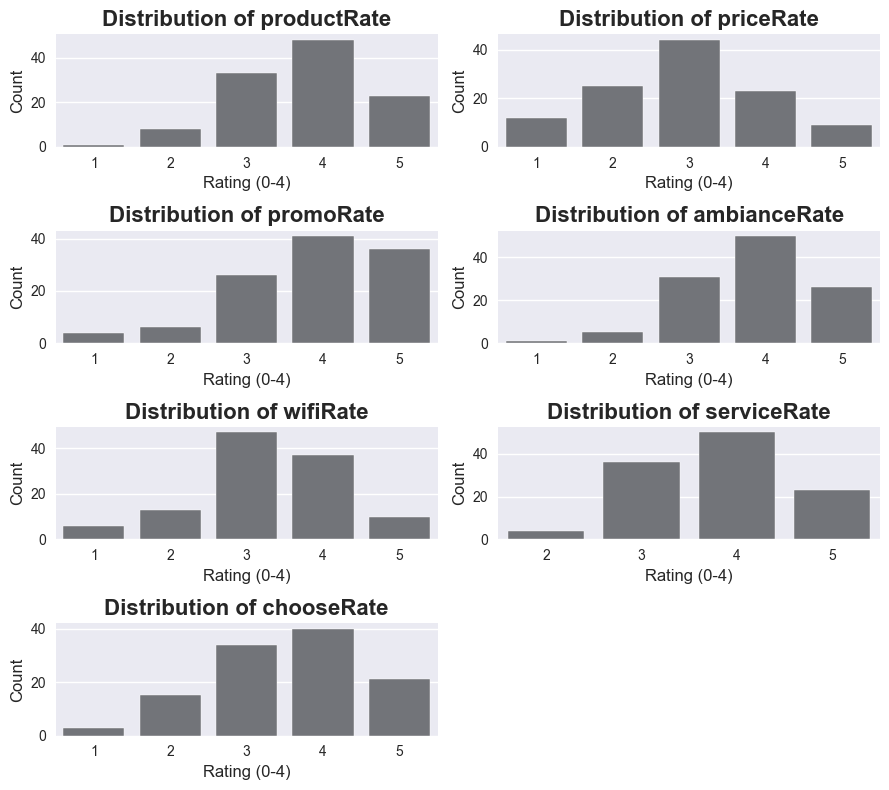

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define rating columns
rating_columns = ['productRate', 'priceRate', 'promoRate', 'ambianceRate', 'wifiRate', 'serviceRate', 'chooseRate']

# Set up the subplots: 2 columns
n_cols = 2
n_rows = (len(rating_columns) + n_cols - 1) // n_cols  # Calculate required rows
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(9, 2 * n_rows))

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each rating column
for idx, col in enumerate(rating_columns):
    sns.countplot(data=df2, x=col, palette=['#71747A'], ax=axes[idx])  # Dark color palette
    axes[idx].set_title(f'Distribution of {col}', fontsize=16, weight='bold')  # Bold titles
    axes[idx].set_xlabel('Rating (0-4)', fontsize=12)  # X-axis label
    axes[idx].set_ylabel('Count', fontsize=12)  # Y-axis label
    axes[idx].tick_params(axis='x', labelsize=10)  # Customize x-ticks
    axes[idx].tick_params(axis='y', labelsize=10)  # Customize y-ticks

# Remove any unused subplots
for idx in range(len(rating_columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


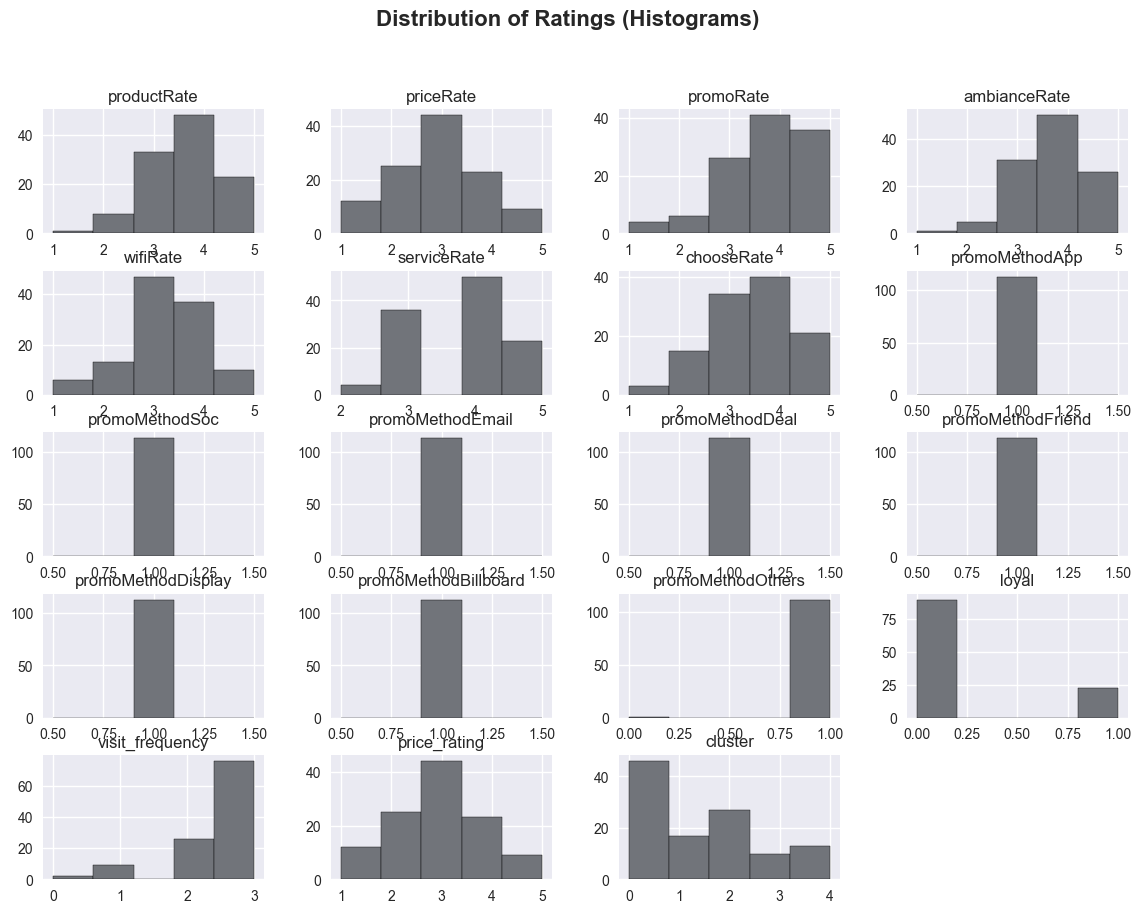

In [150]:
df2.iloc[:, 17:].hist(bins=5, figsize=(14, 10), color='#71747A', edgecolor="black")
plt.suptitle("Distribution of Ratings (Histograms)", fontsize=16, weight="bold")
plt.show()


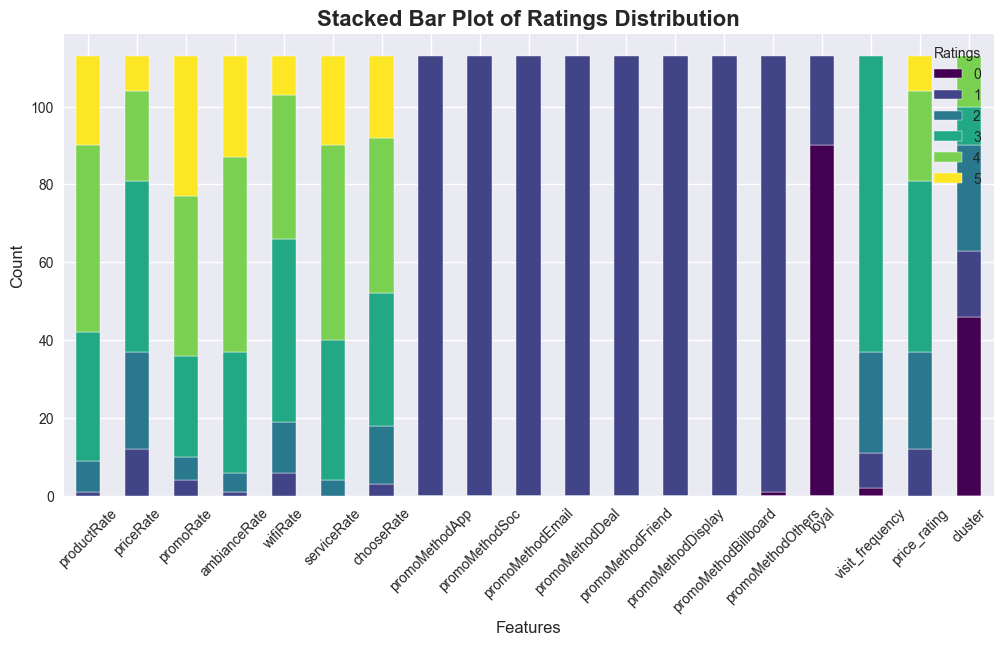

In [151]:
ratings_counts = df2.iloc[:, 17:].apply(pd.Series.value_counts).T
ratings_counts = ratings_counts.fillna(0)  # Fill missing counts with 0

ratings_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Stacked Bar Plot of Ratings Distribution", fontsize=16, weight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.legend(title="Ratings", loc='upper right', fontsize=10)
plt.show()


<h2> Further Recommendations

<div>
    <p><strong>1. Personalized Offers and Discounts:</strong> Analyze user preferences (e.g., frequent purchases, visit patterns) to provide tailored discounts or promotions. For example, offer discounts on their most-purchased items or give loyalty bonuses for repeat visits.</p> <br>
 </div>   
 <div>   <p><strong>2. Leverage Membership Cards:</strong> Promote your membership program by offering exclusive benefits like free upgrades, priority service, or member-only promotions. Provide tiered memberships with added perks for higher tiers.</p></div> <br>

<div>    
    <p><strong>3. Host Events and Workshops:</strong> Create reasons for customers to visit more often by organizing coffee workshops, tastings, barista training sessions, or partnering with local artists, musicians, or creators.</p> <div> <br>

<div>    
    <p><strong>4. Improve In-store Ambiance:</strong> Invest in better lighting, comfortable seating, and soothing music. A welcoming environment encourages longer stays and higher spending.</p></div> <br>

<div>   
    <p><strong>5. Strengthen Online Presence:</strong> Use social media platforms to post engaging content, customer stories, behind-the-scenes videos, or promotions. Include influencer collaborations to reach a broader audience.</p></div> <br>
    
<div>     
    <p><strong>6. Mobile App Integration:</strong> Launch or enhance a mobile app that allows users to place orders, track loyalty points, and receive notifications about exclusive deals and events.</p></div> <br>
    
<div>    
    <p><strong>7. Seasonal and Limited-time Products:</strong> Offer seasonal beverages, pastries, or other products. Limited-time items create urgency and excitement among customers.</p></div> <br>
    
<div>     <p><strong>8. Partner with Local Businesses:</strong> Collaborate with nearby businesses for cross-promotions or bundle deals. For example, offer a "coffee and a book" discount with a local bookstore.</p></div><br> 
 <div>   
    <p><strong>9. Referral Incentives:</strong> Encourage existing customers to refer new ones by providing rewards for both referrer and referee, such as discounts or free items.</p></div> <br>
    
  <div>     <p><strong>10. Enhanced Customer Feedback Mechanism:</strong> Use surveys or feedback tools to gather opinions from customers. Show them their input leads to improvements, which builds loyalty and trust.</p>
</div><br>
